# Transcriptomic Impact of Dysbiosis (Recalled Genera)

Updated version of `Local_analysis/Followup_analyses_after_Luke_talk/Core_species_and_dysbiosis/transcriptomic_impact_of_unusual_microbiomes_plate_5.ipynb`.

- **Dysbiosis calls:** read from `dysbiosis_calls_recalled_genera.csv`, written by `dysbiosis_calls_and_defense_score_recalled_genera.ipynb`. A sample is "High" if its rare genera (< 10% seasonal prevalence) make up more than the threshold set there. Run that notebook first.
- **DESeq2:** as in the original, `~timepoint + High_rare_genera` on raw counts of all plates 1–5 transcriptomes, keeping genes with > {expressed_gene_reads_threshold} total reads that have > 1 read in more than {number_of_samples_expressed_in_threshold} samples.
- **Outputs:** the significant gene list and the background gene list are saved to `Generated_data/` under new names (`deseq_dysbiosis_gene_list_recalled_genera.csv`, `deseq_background_genes_recalled_genera.csv`) for `go_term_enrichment_dysbiosis_recalled_genera.ipynb`. The volcano plot is saved to `Figures/` in this folder, not over the old figure.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pydeseq2.default_inference
import pydeseq2.ds
import pydeseq2.dds
import Go_tools

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

In [2]:
###Define Thresholds
# The rare genera abundance threshold is read from the dysbiosis calls file below
expressed_gene_reads_threshold = 2000
number_of_samples_expressed_in_threshold = 21

In [3]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)
raw_transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_for_norm.csv",
    index_col=0,
)

## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### For remaining duplicated sampIDs, drop the transcriptome with fewer total reads
double_duplicates = (
    trimmed_metadata.loc[trimmed_metadata.duplicated(subset="sampID", keep=False)]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_raw_transcriptome = raw_transcriptome.loc[trimmed_metadata.index]
print("Transcriptomes after removing replicates:", len(trimmed_metadata))

Transcriptomes after removing replicates: 432


In [4]:
# Dysbiosis calls from dysbiosis_calls_and_defense_score_recalled_genera.ipynb
# (rare genera = < 10% prevalence in seasonal plant samples; the abundance
# threshold is set in that notebook)
dysbiosis_calls = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/dysbiosis_calls_recalled_genera.csv",
    index_col="sampID",
)
rare_genera_abundance_threshold = dysbiosis_calls["rare_genera_abundance_threshold"].iloc[0]
print(f"Rare genera abundance threshold: {rare_genera_abundance_threshold}%")

trimmed_metadata["rare_genera_total_abund"] = trimmed_metadata["sampID"].map(
    dysbiosis_calls["rare_genera_total_abund"]
)
missing_microbiome = trimmed_metadata["rare_genera_total_abund"].isna()
print(
    f"Transcriptomes without a microbiome profile: {missing_microbiome.sum()} "
    "(counted as not dysbiotic, as in the original)"
)
trimmed_metadata["rare_genera_total_abund"] = trimmed_metadata[
    "rare_genera_total_abund"
].fillna(0.0)

Rare genera abundance threshold: 1.0%
Transcriptomes without a microbiome profile: 4 (counted as not dysbiotic, as in the original)


## Overlap of old and new dysbiosis calls

Old calls are the species-level rule from the original notebook (rare species = present in ≤ 37 of 372 samples, dysbiotic = > 9.5% of reads in rare species), rebuilt on the same transcriptome samples.

The original notebook's merge duplicated microbiome rows for samples with several transcriptomes, which inflated some rare abundances. The rebuild below doesn't, so it calls 51 dysbiotic samples rather than 58.

In [5]:
old_microbiome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
old_species_table = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/species_core_results.csv"
)
old_rare_species = set(
    old_species_table.loc[old_species_table["n_samples_present"] <= 37, "Species"]
)
old_rare_abund = (
    old_microbiome.loc[old_microbiome["Species"].isin(old_rare_species)]
    .groupby("plantID")["AbundR100"]
    .sum()
)
dysbiosis_overlap = pd.DataFrame(
    {
        "Old (species)": np.where(
            trimmed_metadata["sampID"].map(old_rare_abund).fillna(0.0) > 9.5,
            "Dysbiotic",
            "Not Dysbiotic",
        ),
        "New (genera)": np.where(
            trimmed_metadata["rare_genera_total_abund"] > rare_genera_abundance_threshold,
            "Dysbiotic",
            "Not Dysbiotic",
        ),
    },
    index=trimmed_metadata.index,
)
pd.crosstab(dysbiosis_overlap["Old (species)"], dysbiosis_overlap["New (genera)"], margins=True)

New (genera),Dysbiotic,Not Dysbiotic,All
Old (species),,,
Dysbiotic,23,28,51
Not Dysbiotic,34,347,381
All,57,375,432


In [6]:
import plotly.graph_objects as go

status_colors = {"Dysbiotic": "#d97d54", "Not Dysbiotic": "#30475e"}
overlap_flow = (
    dysbiosis_overlap.groupby(["Old (species)", "New (genera)"]).size().rename("n").reset_index()
)
statuses = ["Dysbiotic", "Not Dysbiotic"]
node_labels = [f"Old: {s}" for s in statuses] + [f"New: {s}" for s in statuses]
old_totals = dysbiosis_overlap["Old (species)"].value_counts().reindex(statuses, fill_value=0)
new_totals = dysbiosis_overlap["New (genera)"].value_counts().reindex(statuses, fill_value=0)
node_totals = list(old_totals) + list(new_totals)

# Pin Dysbiotic above Not Dysbiotic on each side
node_x, node_y = [], []
gap = 0.05
for totals, x in ((list(old_totals), 0.001), (list(new_totals), 0.999)):
    heights = np.array(totals) / sum(totals) * (1 - gap)
    tops = np.array([0, heights[0] + gap])
    node_x += [x, x]
    node_y += list(tops + heights / 2)

overlap_sankey = go.Figure(
    go.Sankey(
        arrangement="fixed",
        node=dict(
            label=[f"{label} (n={n})" for label, n in zip(node_labels, node_totals)],
            color=[status_colors[label.split(": ")[1]] for label in node_labels],
            x=node_x,
            y=node_y,
            pad=18,
            thickness=22,
        ),
        link=dict(
            source=[statuses.index(s) for s in overlap_flow["Old (species)"]],
            target=[2 + statuses.index(s) for s in overlap_flow["New (genera)"]],
            value=overlap_flow["n"].tolist(),
            color=[
                "rgba(217, 125, 84, 0.35)" if s == "Dysbiotic" else "rgba(48, 71, 94, 0.25)"
                for s in overlap_flow["Old (species)"]
            ],
        ),
    )
)
overlap_sankey.update_layout(
    title_text=(
        "Dysbiosis Calls: Old Species-Level vs New Genus-Level "
        f"(rare genera > {rare_genera_abundance_threshold}%)"
    ),
    font_size=12,
    width=900,
    height=500,
)
overlap_sankey.write_image(
    "/Users/michael/Git/Outdoor_microbiome/Recall_genera_update_paper_results/Figures/dysbiosis_calls_old_vs_new_overlap.pdf"
)
overlap_sankey.show()

<Axes: xlabel='rare_genera_total_abund', ylabel='Count'>

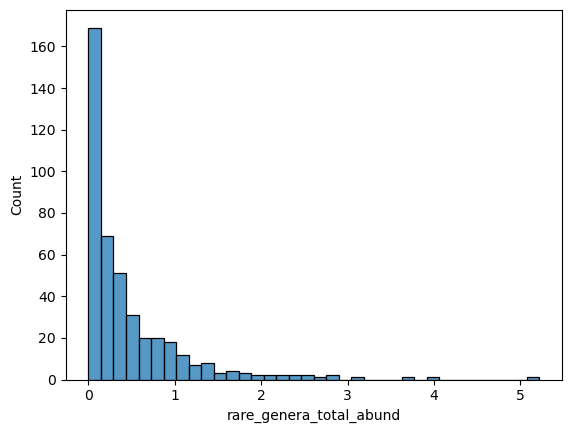

In [7]:
sns.histplot(trimmed_metadata["rare_genera_total_abund"])

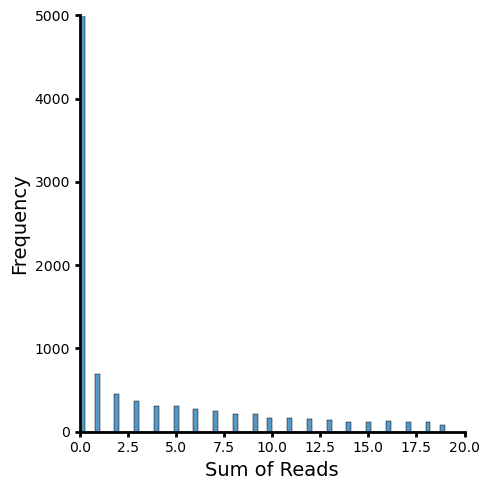

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.histplot(
    trimmed_raw_transcriptome.loc[:, trimmed_raw_transcriptome.sum() < 20].sum()
)
plt.xlabel("Sum of Reads", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xlim((0, 20))
plt.ylim((0, 5000))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [9]:
cleaned_raw_transcriptome = trimmed_raw_transcriptome.loc[
    :, trimmed_raw_transcriptome.sum() > expressed_gene_reads_threshold
]

cleaned_raw_transcriptome

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,ArthCp081,Arthcp087,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCr088,ArthCp088,ArthCp083,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,19,5,26,84,154,118,9,31,314,1534,...,337,2650,0,17,659,0,45,1,15,3
A2450525897_n01_LICRNA01_B01,30,42,31,125,412,218,0,119,829,6287,...,675,7549,0,7,1392,9,125,1,7,11
A2450525897_n01_LICRNA01_C01,30,43,0,74,126,103,6,100,404,2864,...,261,3371,0,28,855,0,131,0,1,2
A2450525897_n01_LICRNA01_E01,19,27,22,41,135,89,3,56,299,3131,...,395,4594,6,10,542,0,44,0,3,5
A2450525897_n01_LICRNA01_F01,11,32,9,126,177,135,4,12,271,1782,...,371,2657,0,0,1402,0,235,0,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0,105,120,161,366,29,5,152,635,5043,...,541,7238,9,0,923,0,55,5,2,35
A2534491401_n01_LICRNA05_E12,0,23,26,166,298,381,19,198,1037,4265,...,1304,9335,0,8,868,44,89,16,50,23
A2534491401_n01_LICRNA05_F12,9,78,26,294,474,700,83,174,798,5139,...,786,4398,0,1,893,0,93,7,0,1


In [10]:
cleaned_raw_transcriptome = cleaned_raw_transcriptome.loc[
    :, (cleaned_raw_transcriptome > 1).sum() > number_of_samples_expressed_in_threshold
]

In [11]:
print("Genes kept for DESeq2:", cleaned_raw_transcriptome.shape[1])

Genes kept for DESeq2: 18032


In [12]:
trimmed_metadata["High_rare_genera"] = (
    trimmed_metadata["rare_genera_total_abund"] > rare_genera_abundance_threshold
)
trimmed_metadata["High_rare_genera"] = trimmed_metadata["High_rare_genera"].replace(
    {True: "High", False: "Low"},
)
trimmed_metadata
trimmed_metadata["High_rare_genera"].value_counts()

High_rare_genera
Low     375
High     57
Name: count, dtype: int64

In [13]:
transcriptome_for_large_deseq = cleaned_raw_transcriptome.loc[trimmed_metadata.index]
transcriptome_for_large_deseq
metadata_for_large_deseq = trimmed_metadata[["timepoint", "High_rare_genera"]]
metadata_for_large_deseq

,timepoint,High_rare_genera
filename,,
A2450525897_n01_LICRNA01_A01,t01,Low
A2450525897_n01_LICRNA01_B01,t01,Low
A2450525897_n01_LICRNA01_C01,t01,Low
A2450525897_n01_LICRNA01_E01,t01,Low
A2450525897_n01_LICRNA01_F01,t01,Low
...,...,...
A2534491401_n01_LICRNA05_D12,c1_t13,Low
A2534491401_n01_LICRNA05_E12,c1_t09,Low
A2534491401_n01_LICRNA05_F12,c1_t04,Low


In [14]:
inference = pydeseq2.default_inference.DefaultInference(n_cpus=6)
dds = pydeseq2.dds.DeseqDataSet(
    counts=transcriptome_for_large_deseq,
    metadata=metadata_for_large_deseq,
    design="~timepoint+High_rare_genera",
    refit_cooks=True,
    inference=inference,
    # n_cpus=8, # n_cpus can be specified here or in the inference object
)

In [15]:
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...


... done in 0.20 seconds.



Fitting dispersions...


... done in 15.17 seconds.

Fitting dispersion trend curve...


... done in 0.50 seconds.

Fitting MAP dispersions...


... done in 15.83 seconds.

Fitting LFCs...


... done in 22.14 seconds.

Calculating cook's distance...


... done in 0.51 seconds.

Replacing 18 outlier genes.



Fitting dispersions...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.05 seconds.

Fitting LFCs...
... done in 0.04 seconds.



In [16]:
ds_high_vs_low_rare_genera_all_samp = pydeseq2.ds.DeseqStats(
    dds, contrast=["High_rare_genera", "High", "Low"], inference=inference
)

In [17]:
ds_high_vs_low_rare_genera_all_samp.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: High_rare_genera High vs Low
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AT1G01010    9.971025        0.145496  0.283821  0.512633  0.608208  0.999759
AT1G01020   51.489923        0.076375  0.115745  0.659857  0.509345  0.999759
AT1G01030   21.630961       -0.048513  0.162001 -0.299459  0.764590  0.999759
AT1G01040  115.240723       -0.050730  0.095007 -0.533955  0.593373  0.999759
AT1G01050  219.913196       -0.048252  0.062354 -0.773838  0.439027  0.999759
...               ...             ...       ...       ...       ...       ...
ArthCt114    5.937831       -1.207594  0.385955 -3.128847  0.001755  0.999759
ArthCr088  164.678025        0.258276  0.159321  1.621109  0.104994  0.999759
ArthCp088   12.007465       -0.026865  0.242656 -0.110712  0.911845  0.999759
ArthCp083   16.245348       -0.504026  0.208741 -2.414605  0.015752  0.999759
ArthCp085  114.438604       -0.042143  0.228836 -0.184164  0.853885  0.9997

... done in 1.71 seconds.



In [18]:
large_deseq_results = ds_high_vs_low_rare_genera_all_samp.results_df
large_deseq_padj_significant = large_deseq_results.loc[
    large_deseq_results["padj"] < 0.05
]
large_deseq_padj_significant

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj


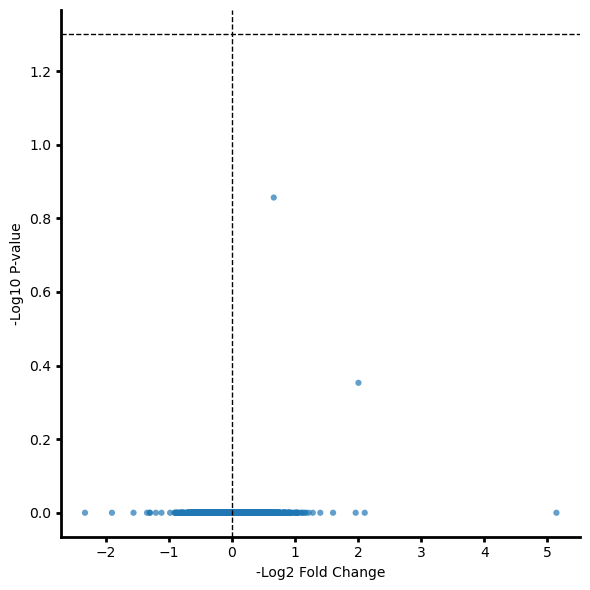

In [19]:
volcano_df = large_deseq_results[["log2FoldChange", "padj"]].copy()
volcano_df = volcano_df.replace([np.inf, -np.inf], np.nan).dropna()
volcano_df["neg_log10_padj"] = -np.log10(volcano_df["padj"].clip(lower=1e-300))
volcano_df["significant"] = volcano_df["padj"] < 0.05

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=volcano_df,
    x="log2FoldChange",
    y="neg_log10_padj",
    hue="significant",
    alpha=0.7,
    s=20,
    linewidth=0,
    ax=ax,
    legend=True,
)
ax.axhline(-np.log10(0.05), linestyle="--", color="black", linewidth=1)
ax.axvline(0, linestyle="--", color="black", linewidth=1)
# ax.set_title("DE in dysbiotic samples")
ax.set_xlabel("-Log2 Fold Change")
ax.set_ylabel("-Log10 P-value")

ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)

ax.spines["top"].set_color("black")
ax.spines["top"].set_linewidth(0)

# ax2.spines["right"].set_color("black")
# ax2.spines["right"].set_linewidth(2)
# ax2.spines["top"].set_color("black")
# ax2.spines["top"].set_linewidth(0)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
sns.despine()
plt.tight_layout()
plt.savefig(
    "/Users/michael/Git/Outdoor_microbiome/Recall_genera_update_paper_results/Figures/volcano_plot_dysbiotic_samples_recalled_genera.pdf",
    dpi=600,
    bbox_inches="tight",
)

In [20]:
volcano_df.sort_values(by="neg_log10_padj", ascending=False).head(40)

,log2FoldChange,padj,neg_log10_padj,significant
AT5G06100,0.662032,0.139139,0.856550,False
AT2G26020,2.004613,0.443438,0.353167,False
AT1G21770,-0.010350,0.999759,0.000104,False
AT3G46940,-0.104947,0.999759,0.000104,False
AT5G03190,0.154113,0.999759,0.000104,False
AT5G55250,-0.073250,0.999759,0.000104,False
AT5G62350,0.025212,0.999759,0.000104,False
AT5G65420,0.020053,0.999759,0.000104,False
AT5G66910,0.278466,0.999759,0.000104,False
DA397_mgp39,-0.241617,0.999759,0.000104,False


In [21]:
volcano_df.value_counts("significant")

significant
False    18032
Name: count, dtype: int64

<Axes: ylabel='Count'>

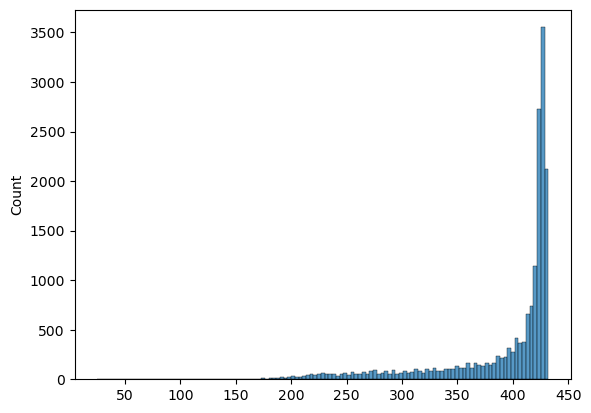

In [22]:
sns.histplot((cleaned_raw_transcriptome > 1).sum())

## GO enrichment of significant genes

In [23]:
background_genes_list = cleaned_raw_transcriptome.columns.tolist()

In [24]:
go_term_matrix = pd.read_csv(
    "/Users/michael/Data/Reference_data/Arabdidopsis_go_matrix_from_tair_gaf.csv",
    index_col=0,
)
go_term_matrix

,GO:0000001,GO:0000009,GO:0000012,GO:0000014,GO:0000023,GO:0000024,GO:0000025,GO:0000026,GO:0000027,GO:0000028,...,GO:2001071,GO:2001080,GO:2001141,GO:2001142,GO:2001143,GO:2001147,GO:2001227,GO:2001280,GO:2001289,GO:2001294
GeneID,,,,,,,,,,,,,,,,,,,,,
AT1G01010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01030,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G67600,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT5G67610,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT5G67620,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
large_deseq_gene_list = large_deseq_padj_significant.index.tolist()
len(large_deseq_gene_list)

0

In [26]:
pd.Series(large_deseq_gene_list).to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/deseq_dysbiosis_gene_list_recalled_genera.csv",
    index=False,
    header=False,
)
pd.Series(background_genes_list).to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/deseq_background_genes_recalled_genera.csv",
    index=False,
    header=False,
)
large_deseq_results.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/deseq_dysbiosis_results_recalled_genera.csv"
)

In [27]:
cont_tables_large = Go_tools.generate_contigency_tables(
    go_annotations=go_term_matrix,
    gene_list=large_deseq_gene_list,
    use_background_genes=True,
    background_genes=background_genes_list,
)

fishers_results_large = Go_tools.fishers_exact_on_contigency_tables(
    all_go_contigency_tables=cont_tables_large,
    original_GO_term_panda=go_term_matrix,
)

corrected_fishers_results_large = Go_tools.multi_hypothesis_correct_fishers_exact(
    fishers_results_large
)

In [28]:
corrected_fishers_results_large.sort_values("P_value").head(30)

,P_value
GO:0000001,1.0
GO:0000009,1.0
GO:0000012,1.0
GO:0000014,1.0
GO:0000023,1.0
GO:0000024,1.0
GO:0000025,1.0
GO:0000026,1.0
GO:0000027,1.0
GO:0000028,1.0


In [29]:
go_term_names = pd.read_csv(
    "/Users/michael/Data/Reference_data/goterm_names.csv", index_col=0
)
go_term_names

,x
GO:0000001,mitochondrion inheritance
GO:0000006,high-affinity zinc transmembrane transporter a...
GO:0000007,low-affinity zinc ion transmembrane transporte...
GO:0000009,"alpha-1,6-mannosyltransferase activity"
GO:0000010,heptaprenyl diphosphate synthase activity
...,...
GO:7770007,L-arginine conjugated cholate hydrolase activity
GO:7770008,L-histidine conjugated cholate hydrolase activity
GO:7770009,L-tryptophan conjugated cholate hydrolase acti...
GO:7770010,GTPBP3-MTO1 complex


In [30]:
named_large_fishers_results = corrected_fishers_results_large.merge(
    go_term_names, left_index=True, right_index=True, how="left"
)
named_large_fishers_results.sort_values("P_value").head(40)

,P_value,x
GO:0000001,1.0,mitochondrion inheritance
GO:0000009,1.0,"alpha-1,6-mannosyltransferase activity"
GO:0000012,1.0,single strand break repair
GO:0000014,1.0,single-stranded DNA endodeoxyribonuclease acti...
GO:0000023,1.0,maltose metabolic process
GO:0000024,1.0,maltose biosynthetic process
GO:0000025,1.0,maltose catabolic process
GO:0000026,1.0,"alpha-1,2-mannosyltransferase activity"
GO:0000027,1.0,ribosomal large subunit assembly
GO:0000028,1.0,ribosomal small subunit assembly


In [31]:
top_40 = named_large_fishers_results.sort_values("P_value").head(40)
top_40_cleaned = top_40.drop(
    index=[
        "GO:0009535",
        "GO:0009570",
        "GO:0009507",
        "GO:0009534",
        "GO:0010319",
        "GO:0010287",
        "GO:0009543",
        "GO:0031977",
        "GO:0009658",
        "GO:0009536",
    ],
    errors="ignore",  # redundant chloroplast terms dropped by hand in the original
)

In [32]:
top_40_cleaned["x"] = top_40_cleaned["x"].str.capitalize()
top_40_cleaned["Neg Log P Val"] = -1 * np.log10(top_40_cleaned["P_value"])
top_40_cleaned

,P_value,x,Neg Log P Val
GO:0000001,1.0,Mitochondrion inheritance,-0.0
GO:0000009,1.0,"Alpha-1,6-mannosyltransferase activity",-0.0
GO:0000012,1.0,Single strand break repair,-0.0
GO:0000014,1.0,Single-stranded dna endodeoxyribonuclease acti...,-0.0
GO:0000023,1.0,Maltose metabolic process,-0.0
GO:0000024,1.0,Maltose biosynthetic process,-0.0
GO:0000025,1.0,Maltose catabolic process,-0.0
GO:0000026,1.0,"Alpha-1,2-mannosyltransferase activity",-0.0
GO:0000027,1.0,Ribosomal large subunit assembly,-0.0
GO:0000028,1.0,Ribosomal small subunit assembly,-0.0


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Mitochondrion inheritance'),
  Text(0, 1, 'Alpha-1,6-mannosyltransferase activity'),
  Text(0, 2, 'Single strand break repair'),
  Text(0, 3, 'Single-stranded dna endodeoxyribonuclease activity'),
  Text(0, 4, 'Maltose metabolic process'),
  Text(0, 5, 'Maltose biosynthetic process'),
  Text(0, 6, 'Maltose catabolic process'),
  Text(0, 7, 'Alpha-1,2-mannosyltransferase activity'),
  Text(0, 8, 'Ribosomal large subunit assembly'),
  Text(0, 9, 'Ribosomal small subunit assembly')])

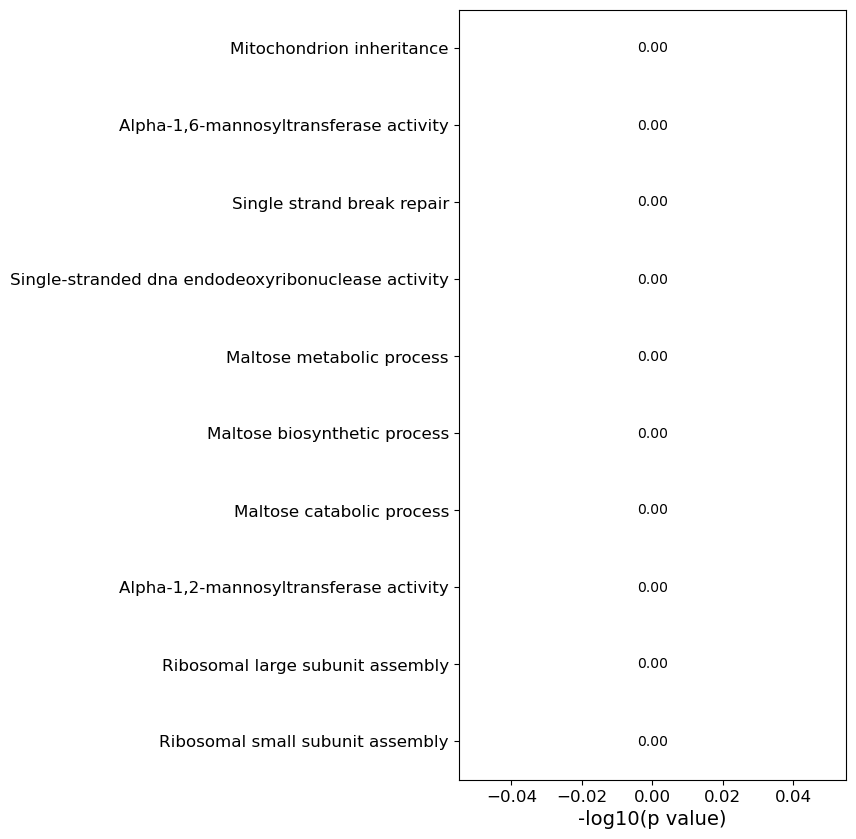

In [33]:
fig, ax = plt.subplots(figsize=(5, 10))
fig.patch.set_facecolor("white")
g = sns.barplot(
    data=top_40_cleaned.head(10), x="Neg Log P Val", y="x", color="tab:green"
)
# plt.ylabel("Euclidian Distance of Coexpressalog from Target Gene", fontsize = 15)
plt.xlabel("-log10(p value)", fontsize=14)
g.set(ylabel=None)
# sns.despine()
g.bar_label(g.containers[0], fmt="%.2f", label_type="center")

g.grid(False)
g.spines["bottom"].set_color("black")
g.spines["left"].set_color("black")
g.spines["top"].set_color("black")
g.spines["right"].set_color("black")
# ax.set_xscale('log')
# plt.xlim((-7,7))
# plt.ylim((0, 1250))
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.savefig('/data/passala/Plots_for_projects/Coexpressolog_paper_plots/updated_for_v11/go_enrichment_updated.svg')

## GO enrichment split by direction of DE

This section computes GO enrichment separately for significantly upregulated and downregulated genes, then plots the top terms for each set.

In [34]:
# Split significant genes by fold-change direction
sig_results = large_deseq_results.loc[large_deseq_results["padj"] < 0.05].copy()
upregulated_gene_list = sig_results.loc[
    sig_results["log2FoldChange"] > 0
].index.tolist()
downregulated_gene_list = sig_results.loc[
    sig_results["log2FoldChange"] < 0
].index.tolist()

print(f"Significant genes: {len(sig_results)}")
print(f"Upregulated genes: {len(upregulated_gene_list)}")
print(f"Downregulated genes: {len(downregulated_gene_list)}")

Significant genes: 0
Upregulated genes: 0
Downregulated genes: 0


In [35]:
downregulated_gene_list

[]

In [36]:
def run_go_enrichment_for_gene_list(gene_list, go_annotations, background_genes):
    if len(gene_list) == 0:
        return pd.DataFrame(columns=["P_value"])

    cont_tables = Go_tools.generate_contigency_tables(
        go_annotations=go_annotations,
        gene_list=gene_list,
        use_background_genes=True,
        background_genes=background_genes,
    )

    fishers_results = Go_tools.fishers_exact_on_contigency_tables(
        all_go_contigency_tables=cont_tables,
        original_GO_term_panda=go_annotations,
    )

    corrected_results = Go_tools.multi_hypothesis_correct_fishers_exact(fishers_results)
    return corrected_results.sort_values("P_value")


up_go_results = run_go_enrichment_for_gene_list(
    gene_list=upregulated_gene_list,
    go_annotations=go_term_matrix,
    background_genes=background_genes_list,
)

down_go_results = run_go_enrichment_for_gene_list(
    gene_list=downregulated_gene_list,
    go_annotations=go_term_matrix,
    background_genes=background_genes_list,
)

up_go_named = up_go_results.merge(
    go_term_names, left_index=True, right_index=True, how="left"
)
down_go_named = down_go_results.merge(
    go_term_names, left_index=True, right_index=True, how="left"
)

if "P_value" in up_go_named.columns:
    up_go_named["Neg Log P Val"] = -np.log10(up_go_named["P_value"].clip(lower=1e-300))
else:
    up_go_named["Neg Log P Val"] = np.nan

if "P_value" in down_go_named.columns:
    down_go_named["Neg Log P Val"] = -np.log10(
        down_go_named["P_value"].clip(lower=1e-300)
    )
else:
    down_go_named["Neg Log P Val"] = np.nan

up_go_named.head(10), down_go_named.head(10)

(Empty DataFrame
 Columns: [P_value, x, Neg Log P Val]
 Index: [],
 Empty DataFrame
 Columns: [P_value, x, Neg Log P Val]
 Index: [])

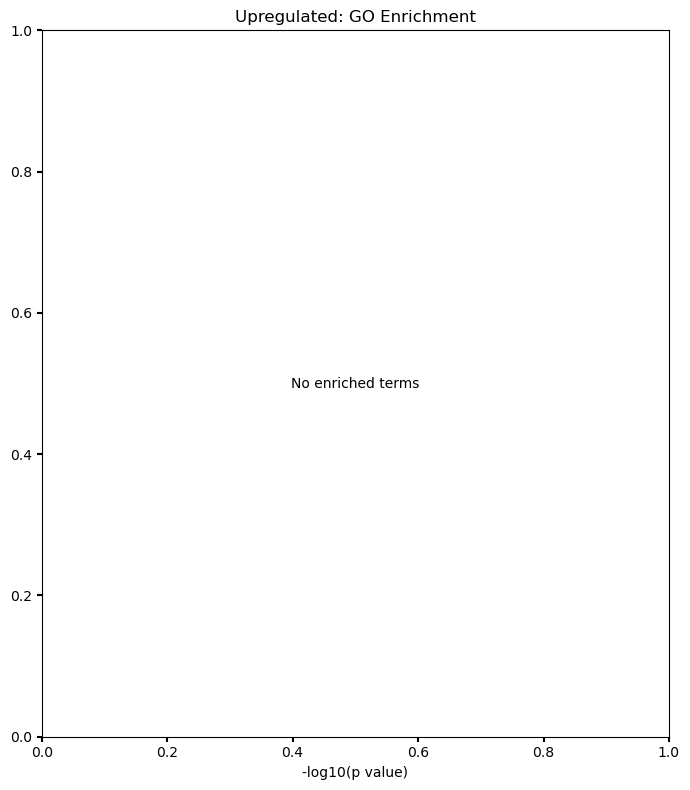

In [37]:
top_n_terms = 10

plot_up = up_go_named.dropna(subset=["x"]).head(top_n_terms).copy()
plot_up["x"] = plot_up["x"].str.capitalize()

fig, ax = plt.subplots(1, 1, figsize=(7, 8))
fig.patch.set_facecolor("white")

if len(plot_up) > 0:
    g = sns.barplot(data=plot_up, x="Neg Log P Val", y="x", color="tab:green", ax=ax)

    # Put p-value labels directly on bars, similar to the earlier GO plot style.
    p_value_labels = [f"p={p_val:.2e}" for p_val in plot_up["P_value"].fillna(np.nan)]
    g.bar_label(g.containers[0], labels=p_value_labels, label_type="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No enriched terms", ha="center", va="center")

ax.set_title("Upregulated: GO Enrichment")
ax.set_xlabel("-log10(p value)")
ax.set_ylabel("")
ax.grid(False)

ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["top"].set_color("black")
ax.spines["right"].set_color("black")
ax.tick_params(axis="both", width=1.5)

plt.tight_layout()

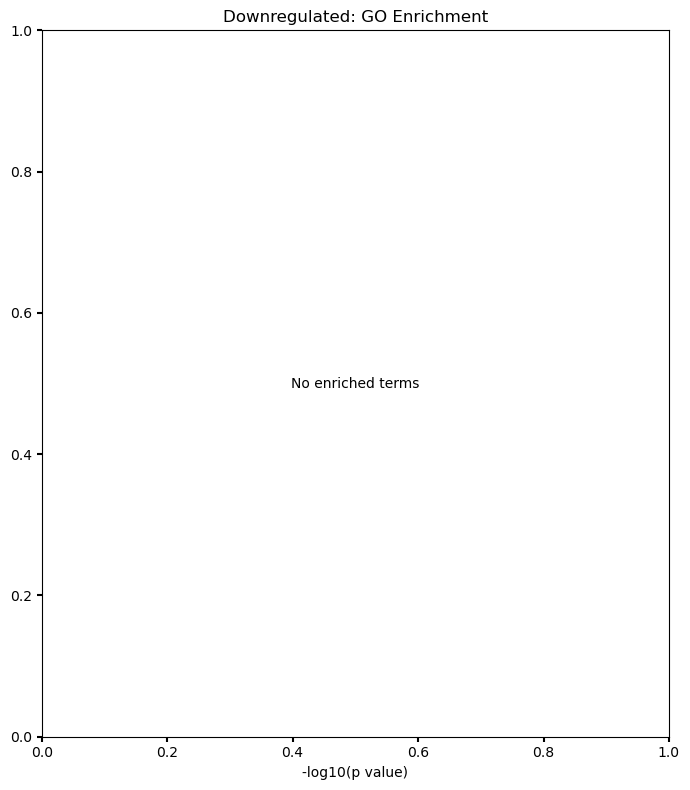

In [38]:
top_n_terms = 10

plot_up = down_go_named.dropna(subset=["x"]).head(top_n_terms).copy()
plot_up["x"] = plot_up["x"].str.capitalize()

fig, ax = plt.subplots(1, 1, figsize=(7, 8))
fig.patch.set_facecolor("white")

if len(plot_up) > 0:
    g = sns.barplot(data=plot_up, x="Neg Log P Val", y="x", color="tab:blue", ax=ax)

    # Put p-value labels directly on bars, similar to the earlier GO plot style.
    p_value_labels = [f"p={p_val:.2e}" for p_val in plot_up["P_value"].fillna(np.nan)]
    g.bar_label(g.containers[0], labels=p_value_labels, label_type="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No enriched terms", ha="center", va="center")

ax.set_title("Downregulated: GO Enrichment")
ax.set_xlabel("-log10(p value)")
ax.set_ylabel("")
ax.grid(False)

ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["top"].set_color("black")
ax.spines["right"].set_color("black")
ax.tick_params(axis="both", width=1.5)

plt.tight_layout()